In [1]:
import os
%load_ext autoreload
%autoreload 2

In [7]:
from google.colab import drive
drive.mount('/content/drive/')
%cd '/content/drive/MyDrive/crytpo_DLOB-main/'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/MyDrive/crytpo_DLOB-main


In [3]:
!pip install -r requirements_lujun.txt

In [4]:
!pip install pytorch-tcn

In [5]:
from tqdm import tqdm

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
from torch.utils.data import Dataset, DataLoader
import gc
import os
import sys
import yaml
from preprocessing.preprocessing import preprocess_lob_data, split_data_chronological, normalize_features
from preprocessing.dataset import create_sequences, LOBSequenceDataset
from training.trainer import Trainer, Config

In [8]:
with open("configs/tcn_32_7_10.cfg", "r") as f:
    config_dict = yaml.safe_load(f)
config = Config(config_dict)

In [9]:
print(config.model.in_features)

7


In [11]:
#import torch
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#print(f"Using device: {device}")

In [12]:
!pip install torch_xla #cloud-tpu-client==0.10 https://storage.googleapis.com/tpu-pytorch/wheels/torch_xla-1.13-cp310-cp310-linux_x86_64.whl

In [13]:
import torch_xla
import torch_xla.core.xla_model as xm

# Set the device to use TPU
device = xm.xla_device()
print(f"Using device: {device}")

Using device: xla:0


In [15]:
print(os.getcwd())

/content/drive/MyDrive/crytpo_DLOB-main


In [16]:
# --- 1. Preprocess Data ---
df_processed = preprocess_lob_data(config)
gc.collect()

Memory Usage: 1543.83 MB
Shape before cleaning (dropna): (4817923, 81)
NaN count before: 0
Shape after cleaning: (4817923, 81)
NaN count after: 0
Calculating alpha dynamically...
Dynamic alpha = 0.000026
Shape after label creation and NaN drop: (4817903, 8)
Label distribution:
label
1    0.554784
2    0.222725
0    0.222491
Name: proportion, dtype: float64
Saving preprocessed data to results/...
Save complete.


0

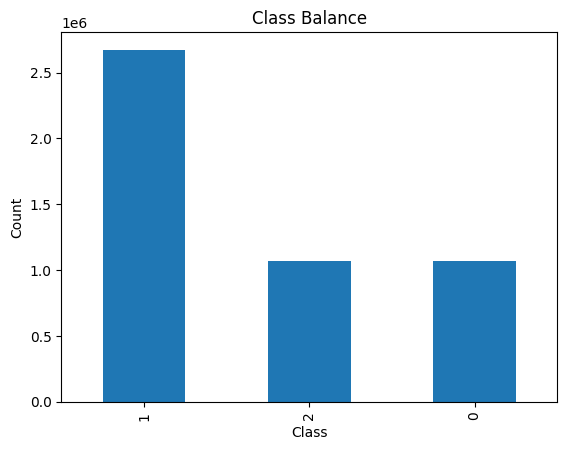

In [17]:
import matplotlib.pyplot as plt
class_counts = df_processed['label'].value_counts()
# Plot
class_counts.plot(kind='bar')
plt.title('Class Balance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [18]:
# --- 2. Split Data ---
train_df, val_df, test_df = split_data_chronological(
    df_processed,
    train_frac=config_dict['split_fractions']['train'],
    val_frac=config_dict['split_fractions']['val'],
    test_frac=config_dict['split_fractions']['test']
)
del df_processed
gc.collect()

Data Split: Train=3372532, Val=722685, Test=722686


2907

In [19]:
train_df.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
10,70207.351562,69387.257812,0.1147,0.032416,69797.304688,-820.093750,0.559310,2
11,70207.351562,69380.929688,0.1147,0.028826,69794.140625,-826.421875,0.598313,2
12,70207.351562,69380.992188,0.1147,0.013600,69794.171875,-826.359375,0.787997,2
13,70207.351562,69387.273438,0.1147,0.009067,69797.312500,-820.078125,0.853482,2
14,70207.351562,69387.273438,0.1147,0.004919,69797.312500,-820.078125,0.917750,2


In [20]:
# --- 3. Normalize Features ---

# Select ONLY numeric feature columns for scaling
# Exclude the 'label' column as well
numeric_cols = train_df.select_dtypes(include=np.number).columns
feature_cols = [col for col in numeric_cols if col != 'label']

# Optional: Print to verify which columns are being scaled
print(f"Columns selected for scaling ({len(feature_cols)}): {feature_cols[:10]}...") # Print first 10

# Check if feature_cols is empty
if not feature_cols:
    raise ValueError("No numerical feature columns found for scaling after excluding 'label'.")

# Call normalize_features with the correctly filtered list
train_df_norm, val_df_norm, test_df_norm, scaler = normalize_features(
    train_df, val_df, test_df, feature_cols
)
train_df_norm.loc[:, "label"] = train_df.loc[:, "label"].copy()
val_df_norm.loc[:, "label"] = val_df.loc[:, "label"].copy()
test_df_norm.loc[:, "label"] = test_df.loc[:, "label"].copy()
del train_df, val_df, test_df
gc.collect()

Columns selected for scaling (7): ['b0', 'a0', 'bq0', 'aq0', 'mid_price', 'spread', 'vol_imbalance_1']...
Normalization applied.


0

In [21]:
train_df_norm.head()

,b0,a0,bq0,aq0,mid_price,spread,vol_imbalance_1,label
10,-1.135054,-1.261911,-0.105994,-0.056245,-1.203296,-0.955049,0.706228,2
11,-1.135054,-1.263469,-0.105994,-0.057524,-1.204087,-0.964610,0.756978,2
12,-1.135054,-1.263453,-0.105994,-0.062948,-1.204079,-0.964516,1.003791,2
13,-1.135054,-1.261908,-0.105994,-0.064562,-1.203294,-0.955026,1.088999,2
14,-1.135054,-1.261908,-0.105994,-0.066040,-1.203294,-0.955026,1.172624,2


In [22]:
config.sequence_length = 100

In [23]:
# --- 4. Create Sequences ---
# Separate features and labels before sequencing
y_train_series = train_df_norm.pop('label').values
X_train_features = train_df_norm[feature_cols].astype(np.float16).values

y_val_series = val_df_norm.pop('label').values
X_val_features = val_df_norm[feature_cols].astype(np.float16).values

y_test_series = test_df_norm.pop('label').values
X_test_features = test_df_norm[feature_cols].astype(np.float16).values

T = config.sequence_length
X_train_seq, y_train_seq = create_sequences(X_train_features, y_train_series, T, precision=np.float16)
X_val_seq, y_val_seq = create_sequences(X_val_features, y_val_series, T, precision=np.float16)
X_test_seq, y_test_seq = create_sequences(X_test_features, y_test_series, T, precision=np.float16)

print("\nSequence Creation Complete:")
print(f"X_train_seq shape: {X_train_seq.shape}, y_train_seq shape: {y_train_seq.shape}")
print(f"X_val_seq shape: {X_val_seq.shape}, y_val_seq shape: {y_val_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}, y_test_seq shape: {y_test_seq.shape}")

del train_df_norm, val_df_norm, test_df_norm # Free memory
del X_train_features, y_train_series, X_val_features, y_val_series, X_test_features, y_test_series
gc.collect()


Sequence Creation Complete:
X_train_seq shape: (3372432, 100, 7), y_train_seq shape: (3372432,)
X_val_seq shape: (722585, 100, 7), y_val_seq shape: (722585,)
X_test_seq shape: (722586, 100, 7), y_test_seq shape: (722586,)


0

In [24]:
# --- 5. Create Datasets & DataLoaders ---
train_dataset = LOBSequenceDataset(X_train_seq, y_train_seq, device=device)
val_dataset = LOBSequenceDataset(X_val_seq, y_val_seq, device=device)
test_dataset = LOBSequenceDataset(X_test_seq, y_test_seq, device=device)

# use first config.model.in_features of features
#in_features = config.model.in_features # depth = in_features / 4
#train_dataset = LOBSequenceDataset(X_train_seq[:,:,:in_features], y_train_seq, device=device)
#val_dataset = LOBSequenceDataset(X_val_seq[:,:,:in_features], y_val_seq, device=device)
#test_dataset = LOBSequenceDataset(X_test_seq[:,:,:in_features], y_test_seq, device=device)

In [25]:
trainer = Trainer(config, train_dataset, val_dataset, test_dataset, torch.device(device))

One batch shape: torch.Size([32, 7, 100])

Datasets and DataLoaders created.
Number of training batches: 105389
Number of validation batches: 22581
Number of testing batches: 22581
Input Size: torch.Size([32, 7, 100])
input.shape: (3372432, 100, 7)
Model: TCN model

🧠 Total parameters: 378,371
🎯 Trainable parameters: 378,371


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [26]:
print(trainer._get_device())

Using TPU (xla:0).
xla:0


In [28]:
print(trainer.device)

xla:0


In [ ]:
trainer.train()

Starting Training
Epochs: 20 | Num Batches: 105389
Epoch[Batch]: [1][0/105389]	Avg_Loss 1.695 (1.695)	 Time 27.623 (27.623)	
